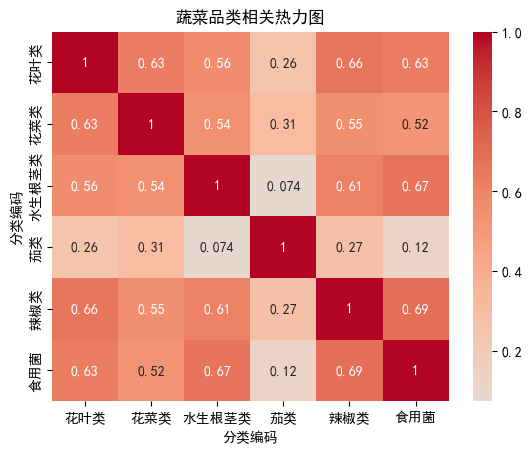

c:\Users\10041\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.draw()
C:\Users\10041\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


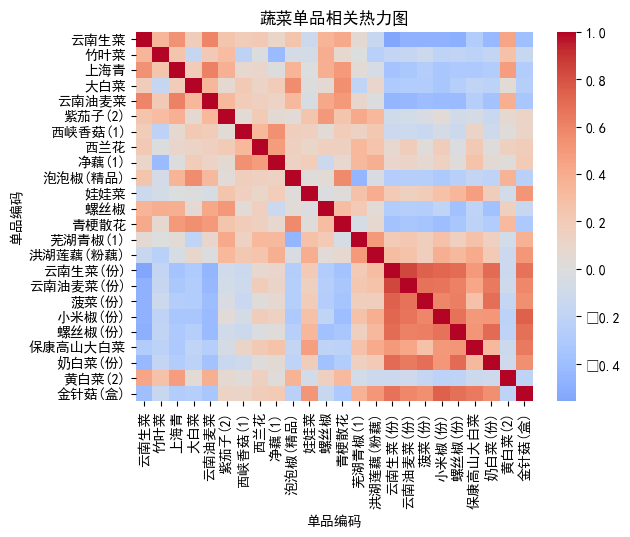

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'SimHei' 

# 读取附件1，附件2； 并创建单品编码/品类编码到对应名称的映射
item_df = pd.read_csv("附件1.csv", encoding="utf-8")
sale_df = pd.read_csv("附件2.csv", encoding="utf-8")
item_code_to_map = item_df.set_index('单品编码')['单品名称'].to_dict()
category_code_to_map = {
    1011010101 : "花叶类",
    1011010201 : "花菜类",
    1011010402 : "水生根茎类",
    1011010501 : "茄类",
    1011010504 : "辣椒类",
    1011010801 : "食用菌"
}

# 将为销量表添加每个销售的更多详细信息
sale_df = sale_df.merge(item_df[['单品编码', '分类编码', '分类名称']], on='单品编码', how='left')
# 创建每个单品的日销售总量
item_daily = sale_df.groupby(['销售日期', '单品编码'])['销量(千克)'].sum().reset_index()
# 创建每个品类的日销售总量
category_daily = sale_df.groupby(['销售日期', '分类编码'])['销量(千克)'].sum().reset_index()
#创建每一个单品的总销售量
item_total = item_daily.groupby(['单品编码'])['销量(千克)'].sum().reset_index()
item_total = item_total.merge(item_df[['单品编码', '单品名称']], on="单品编码")
item_total = item_total.sort_values('销量(千克)', ascending=False)



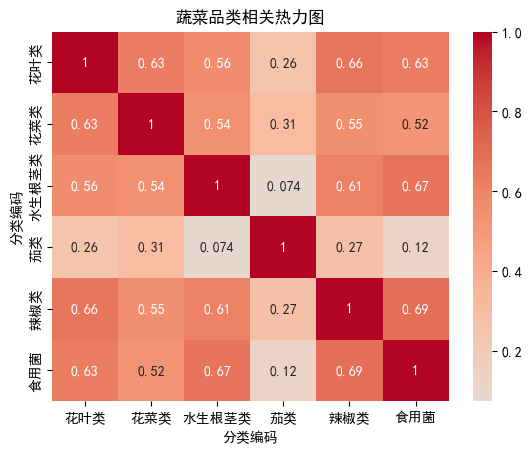

c:\Users\10041\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.draw()
C:\Users\10041\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


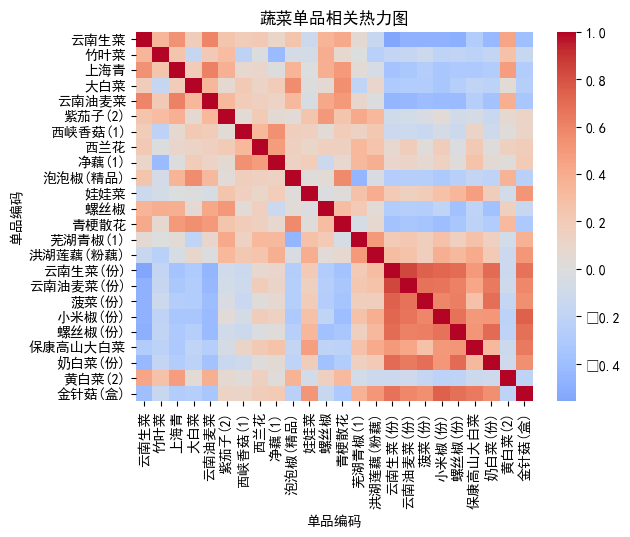

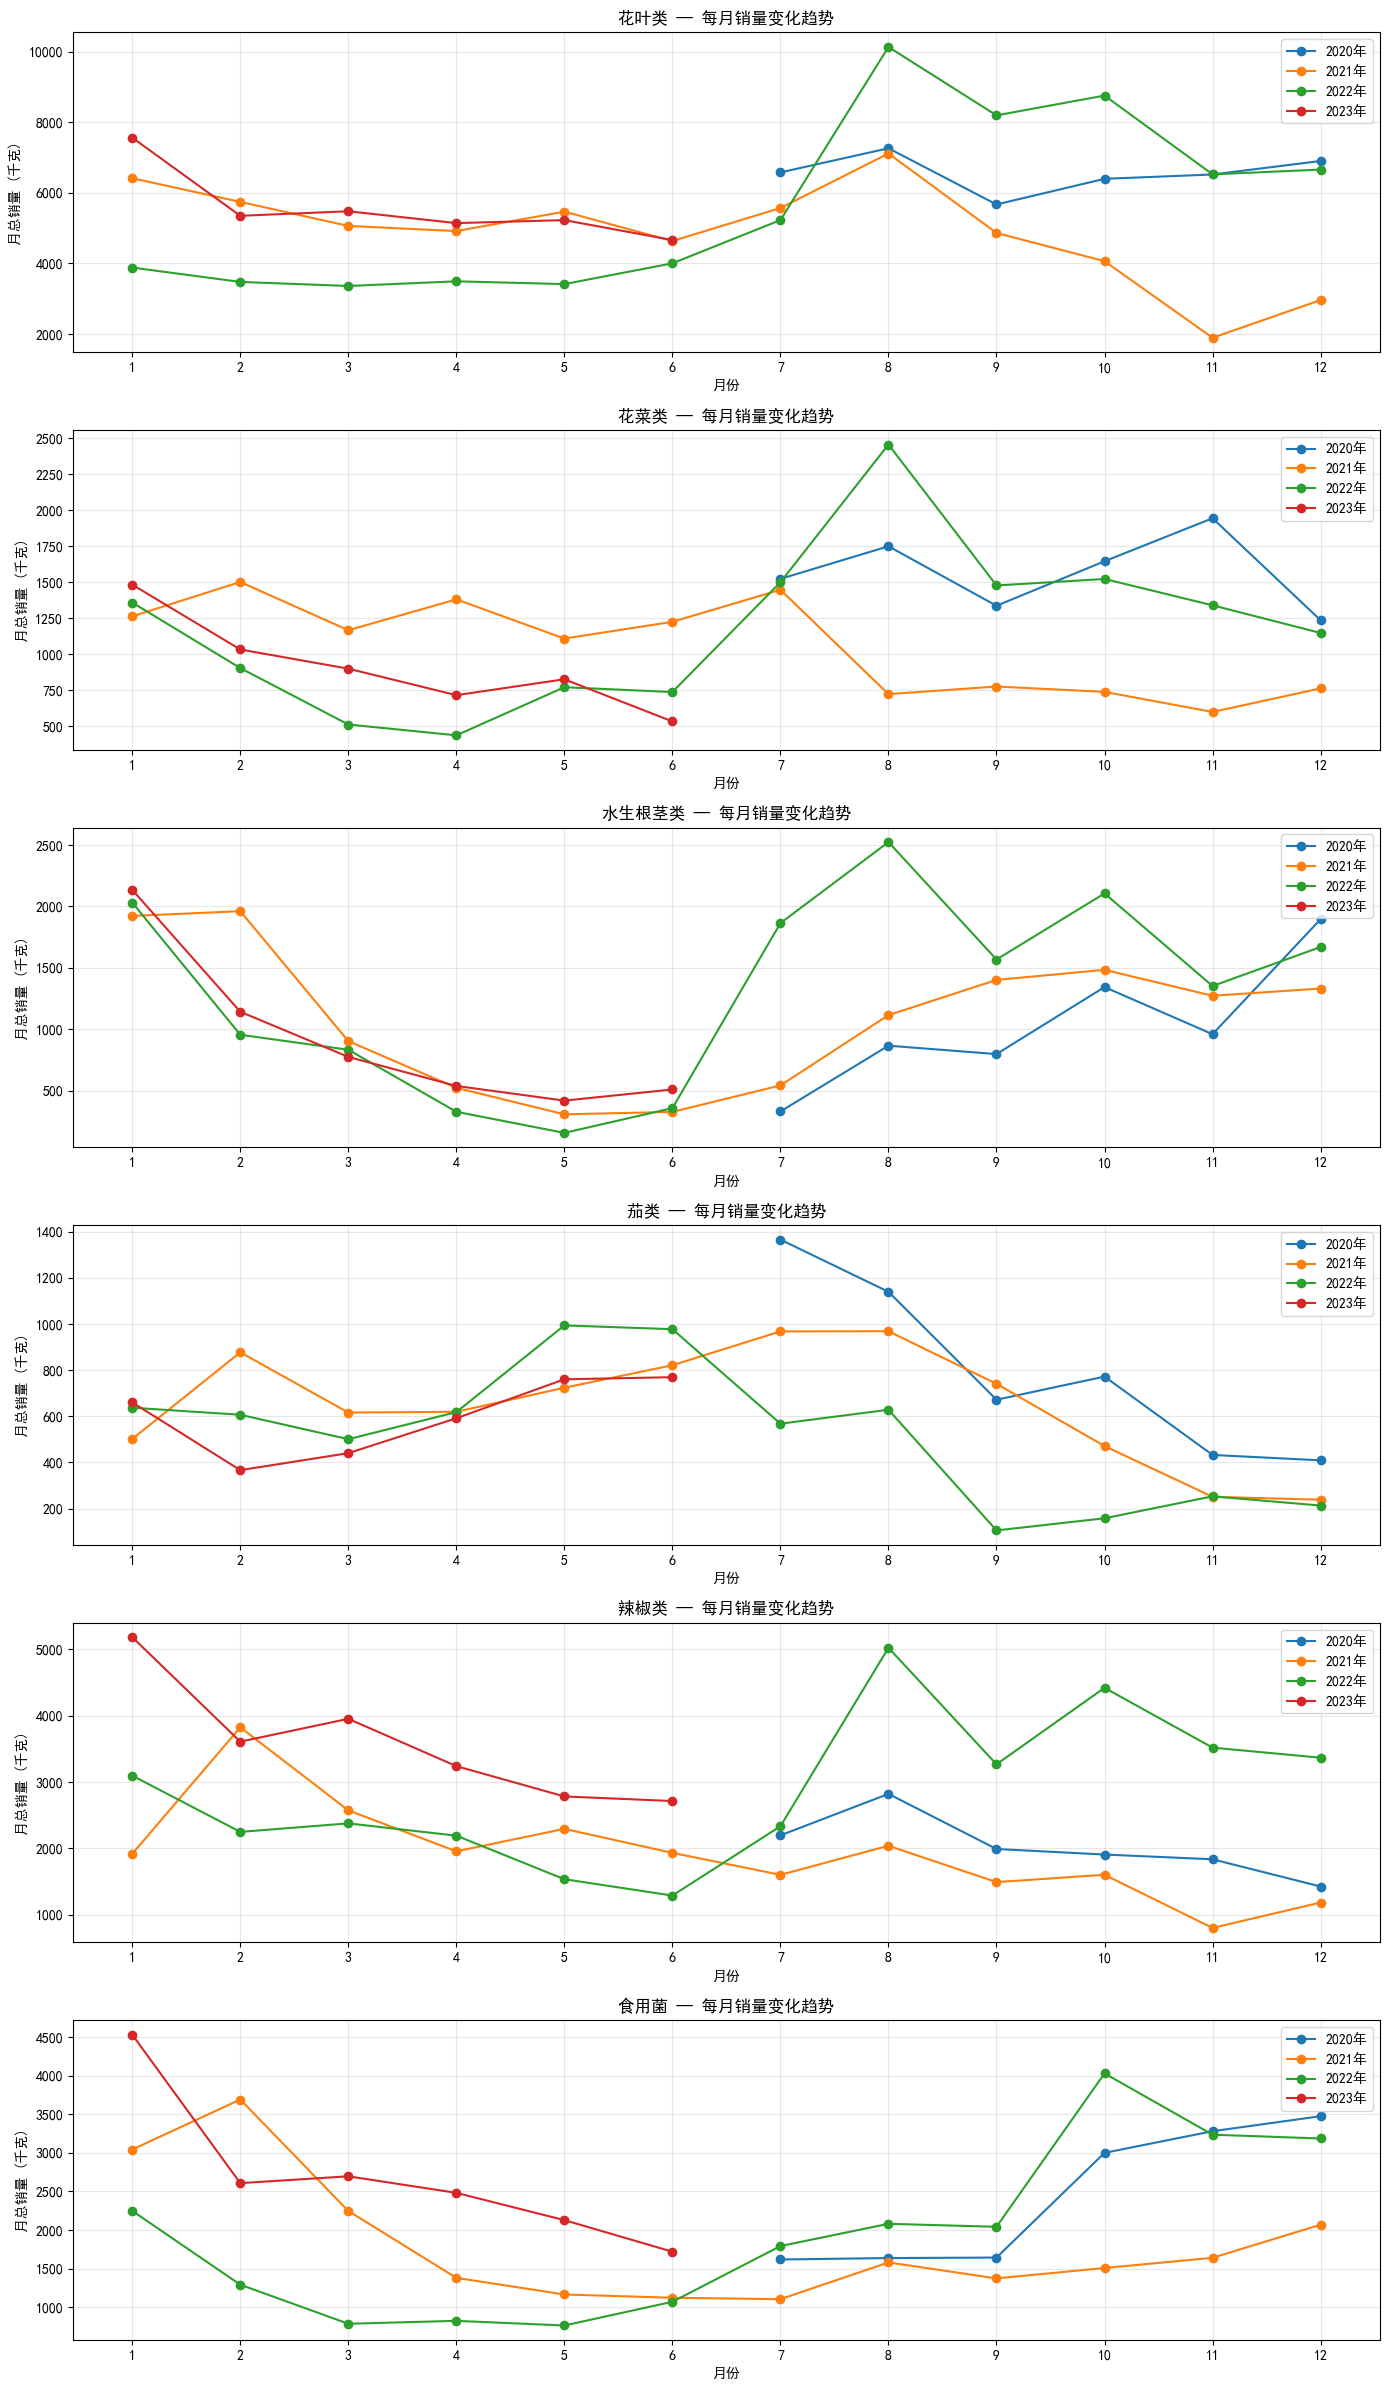

IndexError: index 3 is out of bounds for axis 0 with size 3

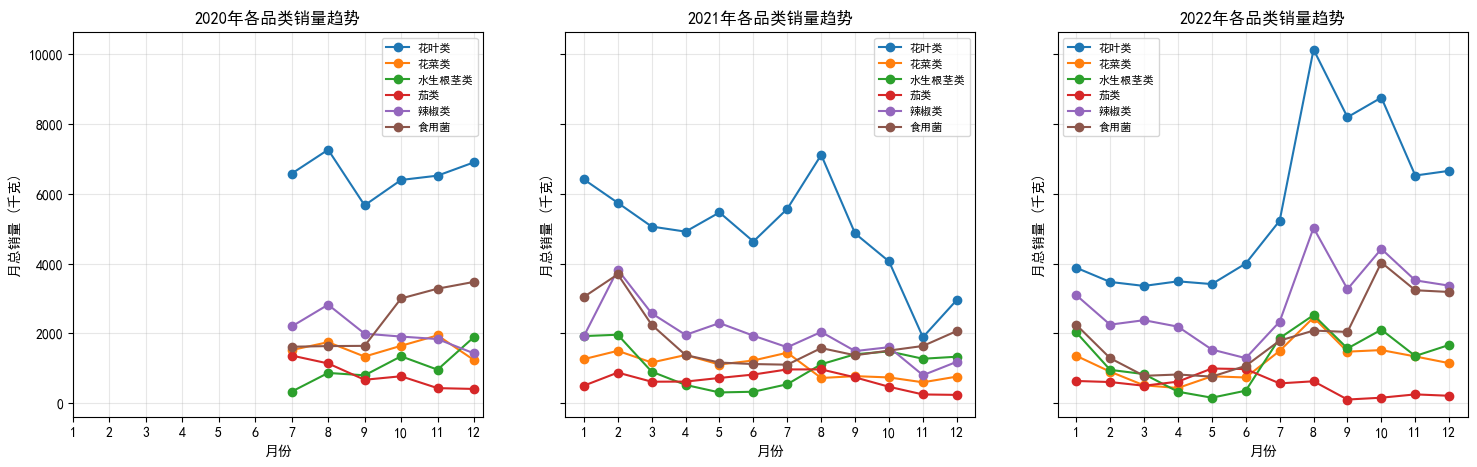

In [42]:

category_daily['销售日期'] = pd.to_datetime(category_daily['销售日期'])
category_daily['年份'] = category_daily['销售日期'].dt.year
category_daily['月份'] = category_daily['销售日期'].dt.month

# 按年月+品类分组，计算月总销量
category_monthly = category_daily.groupby(['年份', '月份', '分类编码'])['销量(千克)'].sum().reset_index()

# 品类名称映射
category_monthly['品类名称'] = category_monthly['分类编码'].map(category_code_to_map)


# ----- 图1：不同品类的热力图 -----
categroy_pivot = category_daily.pivot(index='销售日期', columns='分类编码', values='销量(千克)').fillna(0)
categroy_corr_matrix = categroy_pivot.corr()
categroy_corr_matrix.index = categroy_corr_matrix.index.map(category_code_to_map)
categroy_corr_matrix.columns = categroy_corr_matrix.columns.map(category_code_to_map)

plt.Figure(figsize=(128, 64))
sns.heatmap(categroy_corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("蔬菜品类相关热力图")
plt.show()


# ---- 图2：销量前20的单品图 -----
top_item = item_total.head(24)['单品编码'].tolist()
item_daily_top = item_daily[item_daily['单品编码'].isin(top_item)]
item_pivot = item_daily_top.pivot(index="销售日期", columns="单品编码", values="销量(千克)").fillna(0)
item_corr_matrix = item_pivot.corr()
item_corr_matrix.index = item_corr_matrix.index.map(item_code_to_map)
item_corr_matrix.columns = item_corr_matrix.columns.map(item_code_to_map)

plt.Figure(figsize=(128, 64))
sns.heatmap(item_corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("蔬菜单品相关热力图")
plt.show()


# ----- 图3：每个品类一张子图，不同年份的曲线对比 -----
categories = category_monthly['分类编码'].unique()
n_cats = len(categories)

fig, axes = plt.subplots(n_cats, 1, figsize=(14, 4 * n_cats), sharex=False)

for i, (cat_code, cat_data) in enumerate(category_monthly.groupby('分类编码')):
    cat_name = category_code_to_map.get(cat_code, cat_code)
    ax = axes[i]
    for year, year_data in cat_data.groupby('年份'):
        year_data_sorted = year_data.sort_values('月份')
        ax.plot(year_data_sorted['月份'], year_data_sorted['销量(千克)'],
                marker='o', label=f'{year}年')
    ax.set_title(f'{cat_name} — 每月销量变化趋势', fontsize=12)
    ax.set_xlabel('月份')
    ax.set_ylabel('月总销量 (千克)')
    ax.set_xticks(range(1, 13))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ----- 图4：每年一张子图，所有品类曲线放在一起对比 -----
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for year_idx, (year, year_data) in enumerate(category_monthly.groupby('年份')):
    ax = axes2[year_idx]
    for cat_idx, (cat_code, cat_data) in enumerate(year_data.groupby('分类编码')):
        cat_name = category_code_to_map.get(cat_code, cat_code)
        cat_data_sorted = cat_data.sort_values('月份')
        ax.plot(cat_data_sorted['月份'], cat_data_sorted['销量(千克)'],
                marker='o', color=colors[cat_idx % len(colors)], label=cat_name)
    ax.set_title(f'{year}年各品类销量趋势', fontsize=12)
    ax.set_xlabel('月份')
    ax.set_ylabel('月总销量 (千克)')
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()